<a href="https://colab.research.google.com/github/adithya-prabhu-22/ml_lab_2_4NI23CI007_adithya/blob/main/lab_2_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

df = pd.read_csv("/content/Data.csv")

print(df)


print(df.head())
print(df.info())
print(df.isnull().sum())


df.columns = df.columns.str.strip()

numerical_cols_to_process = ['StudyHours', 'Attendance', 'Marks']
for col in numerical_cols_to_process:

    df[col] = pd.to_numeric(df[col], errors='coerce')

    df[col] = df[col].fillna(df[col].mean())


print(df.isnull().sum())


X = df[['Age', 'StudyHours','Attendance','Marks']]
y = df['Result']
encoder = LabelEncoder()
y = encoder.fit_transform(y)


X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)


print("Training Samples: ", len(X_train))
print("Testing Samples: ", len(X_test))

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Actual :", y_test)
print("Predicted :" , y_pred)

accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy : {accuracy}")

precision = precision_score(y_test,y_pred)
print(f"Precision : {precision}")

recall = recall_score(y_test,y_pred)
print(f"Recall : {recall}")

   St_ID   Age   Gender  StudyHours  Attendance  Marks  Result
0      1    18   Female         2.5          75     55    Pass
1      2    19     Male         5.0          82     68    Pass
2      3    18   Female                      68     61    Pass
3      4    20     Male         2.0          91     90    Pass
4      5    19   Female         5.0          88     78    Pass
5      6    18     Male         1.5          60     45    Fail
6      7    21   Female         7.0                 92    Pass
7      8    20     Male         4.5          90     72    Pass
8      9    20     Male         4.5          80     72    Pass
9     10    18                  3.0          64           Fail
   St_ID   Age   Gender  StudyHours  Attendance  Marks  Result
0      1    18   Female         2.5          75     55    Pass
1      2    19     Male         5.0          82     68    Pass
2      3    18   Female                      68     61    Pass
3      4    20     Male         2.0          91     90 

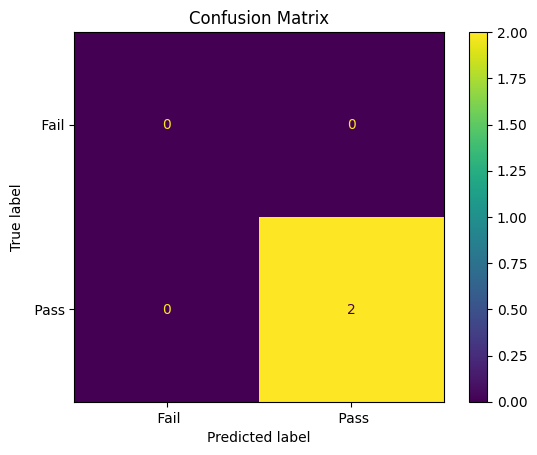

In [71]:
cm = confusion_matrix(y_test, y_pred, labels=encoder.transform(encoder.classes_))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()


In [72]:
df2 = pd.read_csv("/content/StudentsPerformance.csv")

In [73]:
df2

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [74]:
df2.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [81]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [82]:
from sklearn.preprocessing import LabelEncoder


object_cols = df2.select_dtypes(include='object').columns

for col in object_cols:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col])
    print(f"Encoded column '{col}': {le.classes_}")

print('\nDataFrame after Label Encoding:')
display(df2.head())

Encoded column 'gender': ['female' 'male']
Encoded column 'race/ethnicity': ['group A' 'group B' 'group C' 'group D' 'group E']
Encoded column 'parental level of education': ["associate's degree" "bachelor's degree" 'high school' "master's degree"
 'some college' 'some high school']
Encoded column 'lunch': ['free/reduced' 'standard']
Encoded column 'test preparation course': ['completed' 'none']

DataFrame after Label Encoding:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


Training samples: 800
Testing samples: 200

KNN Model Accuracy for Pass/Fail: 0.9050


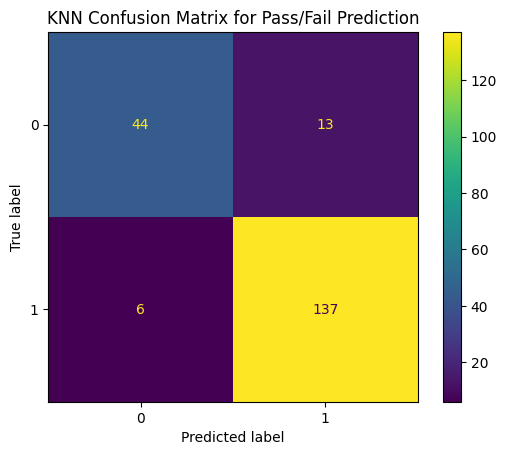

In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


df2['avg_score'] = (df2['math score'] + df2['reading score'] + df2['writing score']) / 3


df2['pass_fail'] = (df2['avg_score'] >= 60).astype(int)

X = df2.drop(['pass_fail', 'avg_score'], axis=1)
y = df2['pass_fail']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nKNN Model Accuracy for Pass/Fail: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("KNN Confusion Matrix for Pass/Fail Prediction")
plt.show()